In [1]:


import jax 
import jax.numpy as jnp


import haiku as hk
import optax

from probjax.nn.transformers import Transformer
from probjax.nn.tokenizer import scalarize, ScalarTokenizer
from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss

from probjax.distributions.sde import VPSDE, BaseSDE
from probjax.distributions import Normal, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions.discrete import Empirical

from probjax.utils.sdeint import sdeint

from functools import partial




I0000 00:00:1702242469.547669    5047 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
2023-12-10 22:07:53.469752: W external/xla/xla/service/gpu/nvptx_compiler.cc:708] The NVIDIA driver's CUDA version is 11.7 which is older than the ptxas CUDA version (11.8.89). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
jax.device_count()

4

In [3]:
from sbibm import get_task

task = get_task("gaussian_linear")
prior = task.get_prior_dist()
simulator = task.get_simulator()

thetas = prior.sample((10000,))
xs = simulator(thetas)

thetas = jnp.array(thetas)
xs = jnp.array(xs)


In [4]:
import matplotlib.pyplot as plt
from probjax.utils.graph import faithfull_mask

# No mask
base_mask = None

# SLCP
# thetas_mask = jnp.eye(thetas.shape[-1], dtype=jnp.bool_) 
# x_i_mask = jax.scipy.linalg.block_diag(*tuple([jnp.ones((2,2), dtype=jnp.bool_)]*4)) 
# base_mask = jnp.block([[thetas_mask, jnp.zeros((thetas.shape[-1], x_i_mask.shape[-1]))], [jnp.ones((x_i_mask.shape[-1], thetas.shape[-1])), x_i_mask]]) 

# Gaussian linear
# thetas_mask = jnp.eye(thetas.shape[-1], dtype=jnp.bool_)
# x_i_mask = jnp.eye(xs.shape[-1], dtype=jnp.bool_)
# base_mask = jnp.block([[thetas_mask, jnp.zeros((thetas.shape[-1], x_i_mask.shape[-1]))], [jnp.eye((x_i_mask.shape[-1])), x_i_mask]])

# Two Moons
#thetas_mask = jnp.eye(thetas.shape[-1], dtype=jnp.bool_)
#x_mask = jnp.ones((thetas.shape[-1], xs.shape[-1]), dtype=jnp.bool_)
#base_mask = jnp.block([[thetas_mask, jnp.zeros((thetas.shape[-1], x_mask.shape[-1]))], [jnp.ones((x_mask.shape[-1], thetas.shape[-1])), x_mask]])

# Mixture of Gaussians
#thetas_mask = jnp.eye(thetas.shape[-1], dtype=jnp.bool_)
#xs_mask = jnp.ones((xs.shape[-1], xs.shape[-1]), dtype=jnp.bool_)
#base_mask = jnp.block([[thetas_mask, jnp.zeros((thetas.shape[-1], xs_mask.shape[-1]))], [jnp.ones((xs_mask.shape[-1], thetas.shape[-1])), xs_mask]])

# plt.imshow(base_mask)

In [5]:

def transformer_model(num_nodes, dim = 40, condition_token_dim=10, num_heads=4, num_layers=5, attn_size=5, widening_factor=4, output_scale_fn=None, base_mask= None):
    
    if output_scale_fn is None:
        output_scale_fn = lambda t, x: x
    
    def model(t,data, data_id, condition_mask, edge_mask=base_mask):
        batch_size, current_nodes, _ = data.shape
        data_id = data_id.reshape(-1,current_nodes)
        condition_mask = condition_mask.reshape(-1,current_nodes)
        

        tokenizer = ScalarTokenizer(dim, num_nodes)
        time_embeder = GaussianFourierEmbedding(128)
        
        # Embedding
        tokens = tokenizer(data_id,data)
        time = time_embeder(t[..., None])
        
        # Conditioning
        condition_token = hk.get_parameter("condition_token", shape=[1,1,condition_token_dim], init=hk.initializers.RandomNormal(0.01))
        condition_mask = condition_mask.reshape(-1,data.shape[-2],1)
        condition_token = condition_mask * condition_token
        condition_token = jnp.broadcast_to(condition_token, tokens.shape[:-1] + (condition_token_dim,))
        tokens = jnp.concatenate([tokens, condition_token], -1)
        
        
        # Forward pass 

        model = Transformer(num_heads=num_heads, num_layers=num_layers, attn_size=attn_size, widening_factor=widening_factor)

        h = model(tokens, context=time, mask=edge_mask)
        out = hk.Linear(1)(h)
        out = output_scale_fn(t, out)
        return out
    
    init_fn, model_fn = hk.without_apply_rng(hk.transform(model))
    return init_fn, model_fn


def init_sde_related(data, name="vpsde", **kwargs):
    """ Initialize the sde and related functions."""
    # VPSDE 
    if name.lower() == "vpsde":
        p0 = Independent(Empirical(data), 1)
        beta_max = kwargs.get("beta_max",10.)
        beta_min = kwargs.get("beta_min", 0.01)
        sde = VPSDE(p0, beta_max=beta_max, beta_min=beta_min)
        T_max = kwargs.get("T_max", 1.)
        T_min = kwargs.get("T_min", 1e-5)

        # Train weight function
        def weight_fn(t):
            t = t.reshape(-1, 1)
            return jnp.clip(1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) ,a_min = 1e-4)
        
        # Model output scale function
        def output_scale_fn(t, x):
            scale = jnp.sqrt(jnp.sum(sde.marginal_variance(t[..., None], x0=jnp.ones_like(x)), -1))
            return 1/scale[..., None] * x
        
    else:
        raise NotImplementedError()
    
    return sde, T_min, T_max, weight_fn, output_scale_fn


def run_train_transformer_model(key, params, opt_state, data, node_id, num_epochs, num_steps, batch_size,  update, print_every=100):
    
     # Set up stuff for multi-device training
    num_devices = jax.device_count()
    batch_size_per_device = batch_size // num_devices
    
    # Replicated for multiple devices
    replicated_params = jax.tree_map(lambda x: jnp.array([x] * num_devices), params)
    replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * num_devices), opt_state)

    for j in range(num_epochs):
        l = 0
        for i in range(num_steps):
            key, key_batch, key_update = jax.random.split(key, 3)
            data_batch = jax.random.choice(key_batch,data, shape=(num_devices, batch_size_per_device, ), axis=0)
            node_id_batch = jnp.repeat(node_id[None,...], num_devices, axis=0)
            loss, replicated_params, replicated_opt_state = update(replicated_params, replicated_opt_state, jax.random.split(key_update, (num_devices,)), data_batch, node_id_batch)
            l += loss[0] /num_steps
        if (j % print_every) == 0:     
            print("Train loss: ",l)
            
    params = jax.tree_map(lambda x: x[0], replicated_params)
    
    return params



class ACSE:
    def __init__(self, params, model_fn, sde, T_min, T_max) -> None:
        self.params = params
        self.model_fn = model_fn
        self.sde = sde

        self.T_min = T_min
        self.T_max = T_max

        self.marginal_end_std = jnp.squeeze(sde.marginal_stddev(jnp.array([self.T_max])))
        self.marginal_end_mean = jnp.squeeze(sde.marginal_mean(jnp.array([self.T_max])))
        
        self.node_id = None
        self.condition_mask = None
        

        
        
        
    def sample(self, num_samples, x_o, num_steps=500, node_id = None, condition_mask = None, edge_mask=None, rng=None, **kwargs):
        if node_id is None:
            node_id = self.node_id
        if condition_mask is None:
            condition_mask = self.condition_mask
        
        if condition_mask is not  None:
            condition_mask = condition_mask.astype(jnp.bool_)
        if edge_mask is not None:
            edge_mask = edge_mask.astype(jnp.bool_)
            
        assert node_id is not None, "node_id must be provided, or set as default"
        assert condition_mask is not None, "condition_mask must be provided, or set as default"
        
        key1, key2 = jax.random.split(rng, 2)
        drift, diffusion = self._init_backward_sde(node_id, condition_mask, edge_mask)
        x_T = jax.random.normal(key1, (num_samples, node_id.shape[-1],)) * self.marginal_end_std + self.marginal_end_mean
        condition_mask = condition_mask.reshape(x_T.shape[-1])
        x_T = x_T.at[...,condition_mask].set(x_o.reshape(-1))
        keys = jax.random.split(key2, (num_samples,))
        ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal",**kwargs), in_axes= (0, None, None, 0, None), out_axes=0)(keys, drift, diffusion, x_T, jnp.linspace(0., self.T_max-self.T_min, num_steps))
        final_samples = ys[:, -1, ...][:,~condition_mask]
        final_samples = final_samples.reshape((num_samples, -1))
        return final_samples
        
    
    def log_prob(self, val, x_o, **kwargs):
        # Add backward ode to compute log_prob
        raise NotImplementedError()
    
    def set_default_node_id(self, node_id):
        self.node_id = node_id
    
    def set_default_condition_mask(self, condition_mask):
        self.condition_mask = condition_mask

    
        
    def _init_backward_sde(self, node_id = None, condition_mask = None, edge_mask=None):
        def drift_backward(t, x):
            t = (self.T_max-t)
            score = self.model_fn(self.params, jnp.atleast_1d(t), x.reshape(-1, x.shape[-1], 1), node_id, condition_mask, edge_mask=edge_mask).reshape(x.shape)
            drift = self.sde.drift(t, x)  - self.sde.diffusion(t, x)**2 * score
            return -drift.reshape(x.shape) * (1-condition_mask.reshape(x.shape))
        
        def diffusion_backward(t, x):
            t = (self.T_max-t)
            return self.sde.diffusion(t, x).reshape(x.shape) * (1-condition_mask.reshape(x.shape))
        
        return drift_backward, diffusion_backward
    



In [23]:
rng = jax.random.PRNGKey(0)

theta_dim = thetas.shape[-1]
x_dim = xs.shape[-1]
data = jnp.hstack([thetas, xs])
data = data[..., None]
node_id = jnp.arange(theta_dim + x_dim)

sde, T_min,T_max, _weight_fn, output_scale_fn = init_sde_related(data)
weight_fn = lambda t: _weight_fn(t).reshape(-1,1,1)




In [24]:
init_fn, model_fn = transformer_model(theta_dim + x_dim, output_scale_fn=output_scale_fn)

rng, rng_init = jax.random.split(rng)
params = init_fn(rng_init, jnp.ones((10,)) , data[:10], node_id, jnp.zeros_like(data[:10]))

In [25]:
total_number_steps = max(min(data.shape[0] * 3, 100000), 5000)
batch_size = 5000

print_every = total_number_steps // 10
learning_rate = 1e-3
schedule = optax.linear_schedule(learning_rate, 0., total_number_steps//2, total_number_steps//2)
optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adam(schedule))
opt_state = optimizer.init(params)

In [26]:
# Training loop
@jax.jit
def loss_fn(params, key, data, node_id):
    key_times, key_loss, key_condition = jax.random.split(key,3)
    times = jax.random.uniform(key_times, (data.shape[0],), minval=T_min, maxval =1.)
    
    key_choice, key_prob, key_bernoulli = jax.random.split(key_condition,3)
    
    # Structured conditioning
    condition_mask = jax.random.choice(key_choice, jnp.array([[0] * (theta_dim+x_dim)] + [[0] * theta_dim + [1] * x_dim] + [[1]* theta_dim + [0] * x_dim, jax.random.bernoulli(key_prob,0.3, shape=(data.shape[1],)), jax.random.bernoulli(key_bernoulli,0.7, shape=(data.shape[1],))] ), shape = (data.shape[0],), p = jnp.array([0.2,.2,0.2, 0.2, 0.2]), axis=0)
    if base_mask is not None:
        edge_mask = jax.vmap(lambda x,y: faithfull_mask(x,y, condition_node_value=False), in_axes=(None, 0))(base_mask, condition_mask)
    else:
        edge_mask = None
    
    # Randomly choose to condition on a few nodes
    #condition_mask = jax.random.bernoulli(jax.random.PRNGKey(0), jax.random.beta(jax.random.PRNGKey(1),1., 4., shape=(data.shape[0],1)), shape=(data.shape[0],data.shape[1])) # More likely to condition on a few nodes
    loss = denoising_score_matching_loss(params, key_loss, times, data, loss_mask=condition_mask, model_fn = model_fn, mean_fn = sde.marginal_mean, std_fn=sde.marginal_stddev, weight_fn=weight_fn, data_id=node_id, condition_mask=condition_mask, edge_mask=edge_mask)
    return loss

@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, key, data, node_id):
    loss, grads = jax.value_and_grad(loss_fn)(params, key, data, node_id)

    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [27]:
partial(jax.jit, static_argnums=(1,4))
def base_batch_sampler(key, batch_size, data, node_id, num_devices=1):
    assert data.ndim == 3, "Data must be 3D, (num_samples, num_nodes, dim)"
    assert node_id.ndim == 2 or node_id.ndim == 1, "Node id must be 2D or 1D, (num_nodes, dim) or (num_nodes,)"
    
    data_batch = jax.random.choice(key,data, shape=(num_devices, batch_size), axis=0)
    node_id_batch = jnp.repeat(node_id[None,...], num_devices, axis=0).astype(jnp.int32)

    return data_batch, node_id_batch
    
    


In [28]:
# rng, rng_train = jax.random.split(rng)
# params = run_train_transformer_model(rng_train, params, opt_state, data, node_id, num_epochs, num_steps, batch_size, update, print_every=print_every)
    

In [29]:
# Set up stuff for multi-device training
def run_train_transformer_model(key, params, opt_state, data, node_id, total_number_steps, batch_size,  update, batch_sampler, loss_fn, print_every=100, val_every=100, validation_fraction=0.05, val_repeat=2):
    
    # Set up stuff for multi-device training
    num_devices = jax.device_count()
    batch_size_per_device = batch_size // num_devices

    # Validation loss 
    data_val, data_train = jnp.split(data, [max(int(validation_fraction*data.shape[0]), 1)], axis=0)
    data_val = jnp.repeat(data_val, val_repeat, axis=0) # Multiple Monte Carlo samples for validation loss
    sampler = partial(batch_sampler, data=data_train, node_id=node_id, num_devices=num_devices)

    # Replicated for multiple devices
    replicated_params = jax.tree_map(lambda x: jnp.array([x] * num_devices), params)
    replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * num_devices), opt_state)

    early_stopping_counter = 0

    l_val = None
    l_train = None
    min_l_val = 1e10
    early_stopping_params = None

    for j in range(total_number_steps):

        key, key_batch, key_update, key_val = jax.random.split(key, 4)
        data_batch, node_id_batch = sampler(key_batch, batch_size_per_device)
        loss, replicated_params, replicated_opt_state = update(replicated_params, replicated_opt_state, jax.random.split(key_update, (num_devices,)), data_batch, node_id_batch)
        # Train loss 
        if j == 0:
            l_train = loss[0]
        else:
            l_train = 0.9 * l_train + 0.1 * loss[0] 
           
        # Validation loss  
        if validation_fraction > 0 and ((j % val_every) == 0) and j > 100:
            l_val = loss_fn(jax.tree_map(lambda x: x[0], replicated_params), key_val, data_val, node_id)
                
            if (l_val/l_train > 1.1):
                early_stopping_counter += 1
            else:
                early_stopping_counter = 0
                
            if l_val < min_l_val:
                min_l_val = l_val
                early_stopping_params = jax.tree_map(lambda x: x[0], replicated_params)
        
        if early_stopping_counter > 5:
            return early_stopping_params, jax.tree_map(lambda x: x[0], replicated_opt_state)    
        
        # Print
        if (j % print_every) == 0:     
            print("Train loss: ",l_train)
            if l_val is not None:
                print("Validation loss: ", l_val, early_stopping_counter)
            
    params = jax.tree_map(lambda x: x[0], replicated_params)
    opt_state = jax.tree_map(lambda x: x[0], replicated_opt_state)
    return params, opt_state

In [30]:
rng, rng_train = jax.random.split(rng)
params, opt_state = run_train_transformer_model(rng_train, params, opt_state, data, node_id, total_number_steps, batch_size, update, base_batch_sampler, loss_fn, print_every=print_every, val_every=total_number_steps//1000, validation_fraction=0.05)
    

Train loss:  13.349455
Train loss:  2.7169206
Validation loss:  2.2098231 0
Train loss:  2.407001
Validation loss:  1.845211 0
Train loss:  2.3842068
Validation loss:  2.2226741 0
Train loss:  2.6331592
Validation loss:  2.572667 0
Train loss:  2.5204592
Validation loss:  2.1349773 0
Train loss:  2.5351093
Validation loss:  1.9384184 0
Train loss:  2.4863493
Validation loss:  5.2294188 1
Train loss:  2.3372648
Validation loss:  2.315718 0
Train loss:  2.535542
Validation loss:  2.8547335 1


In [31]:
model = ACSE(params, model_fn, sde, T_min, T_max)

In [32]:
from sbi.analysis.sbc import c2st
import torch
import numpy as np

In [33]:
condition_mask = jnp.array([0] * theta_dim + [1] * x_dim, dtype=jnp.bool_)
model.set_default_node_id(node_id)
model.set_default_condition_mask(condition_mask)

In [34]:
edge_mask = None

In [35]:
# edge_mask = faithfull_mask(base_mask, condition_mask, condition_node_value=False)

In [36]:
# plt.imshow(edge_mask, vmin=0, vmax=1)

In [37]:

c2sts = []
for i in range(1,11):
    x_o = task.get_observation(i)
    samples_post = task.get_reference_posterior_samples(i)
    x_o = jnp.array(x_o)
    samples_est = model.sample(10000, x_o, rng=jax.random.PRNGKey(i), edge_mask=edge_mask)
    metric = c2st(torch.tensor(np.array(samples_est)), samples_post)
    print("C2ST: ", metric)

C2ST:  tensor([0.7357])


KeyboardInterrupt: 

(<Figure size 1000x1000 with 100 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 5'>,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: xlabel='dim 6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: xlabel='dim 7'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, 

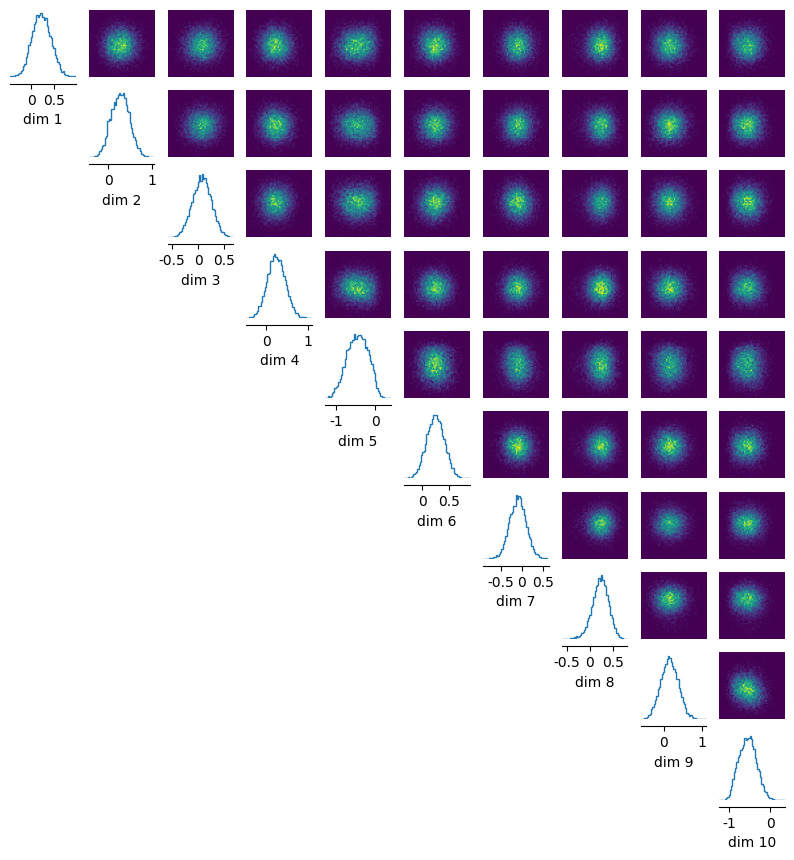

In [67]:
from sbi.analysis import pairplot
import numpy as np

pairplot(np.array(samples_est))